In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso,Ridge,LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

In [2]:
data = load_iris()
x = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Logistic Regression

In [3]:

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [4]:
models = {
    'logistic_regression': LogisticRegression(),
    'lasso': LogisticRegression(penalty='l1',solver='liblinear'),
    'ridge': LogisticRegression(penalty='l2')
}
result=[]
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)*100
    result.append({'Model: ':name,'accuracy: ':acc,'coef':model.coef_})
    


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [5]:
result

[{'Model: ': 'logistic_regression',
  'accuracy: ': 100.0,
  'coef': array([[-0.39339167,  0.96259823, -2.37510533, -0.99874638],
         [ 0.5083984 , -0.25487182, -0.21301388, -0.77575679],
         [-0.11500673, -0.70772641,  2.58811922,  1.77450317]])},
 {'Model: ': 'lasso',
  'accuracy: ': 100.0,
  'coef': array([[ 0.        ,  2.36296515, -2.67175667,  0.        ],
         [ 0.69390076, -1.78877443,  0.24455336, -0.88943394],
         [-2.20291285, -2.83303689,  3.20453255,  3.72051039]])},
 {'Model: ': 'ridge',
  'accuracy: ': 100.0,
  'coef': array([[-0.39339167,  0.96259823, -2.37510533, -0.99874638],
         [ 0.5083984 , -0.25487182, -0.21301388, -0.77575679],
         [-0.11500673, -0.70772641,  2.58811922,  1.77450317]])}]

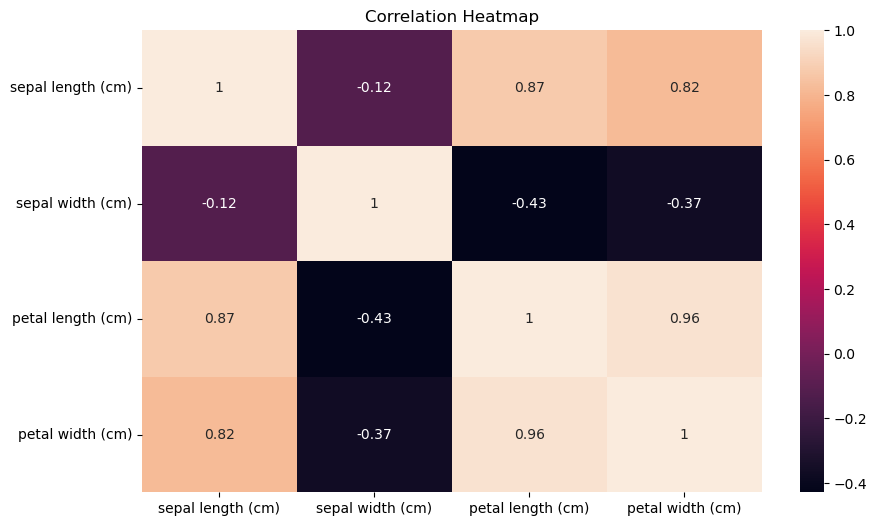

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(x.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

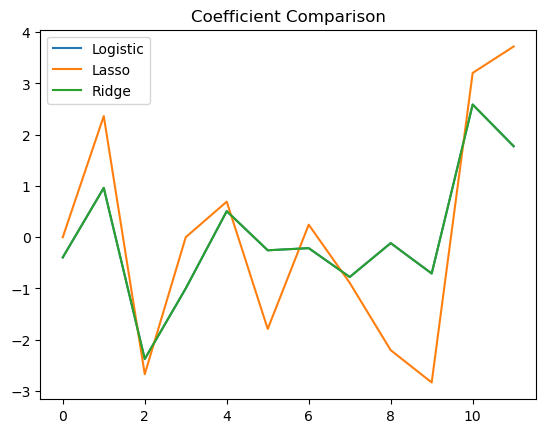

In [7]:
plt.plot(result[0]['coef'].flatten(), label='Logistic')
plt.plot(result[1]['coef'].flatten(), label='Lasso')
plt.plot(result[2]['coef'].flatten(), label='Ridge')

plt.legend()
plt.title("Coefficient Comparison")
plt.show()